In [1]:
import numpy as np
import scipy as sc
import matplotlib.pyplot as plt

In [2]:
hbar = 1
std_x = 1
std_p = hbar / std_x
x0 = 10
p0 = 10

In [3]:
def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_p * np.sqrt(2 * np.pi)))
    p = hbar * k
    phase = np.exp(-1j / hbar * (p - p0) * x0)
    gaussian = np.exp(-((p - p0) / std_p) ** 2 / 4)
    return np.sqrt(hbar) * normalization * gaussian * phase

def wave(t, k, x):
    p = hbar * k
    position = np.exp(1j / hbar * p * x)
    time_evolution = np.exp(1j / hbar * p ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


In [4]:
hbar = 1
std_x = 1
std_k = 1 / std_x
x0 = 1
k0 = 4

In [5]:
def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


In [6]:
import scipy as sc

print(sc.integrate.quad(lambda k : np.abs(gaussian_envelope(k)) ** 2, -10, 30))
print(sc.integrate.quad(lambda x : np.abs(np.sum([wave(0, k, x) * 0.01 for k in np.arange(-10, 30, 0.01)])) ** 2, -10, 30))

(1.0000000000000089, 5.532149277189518e-09)
(1.0000000000000426, 2.796776078973067e-09)


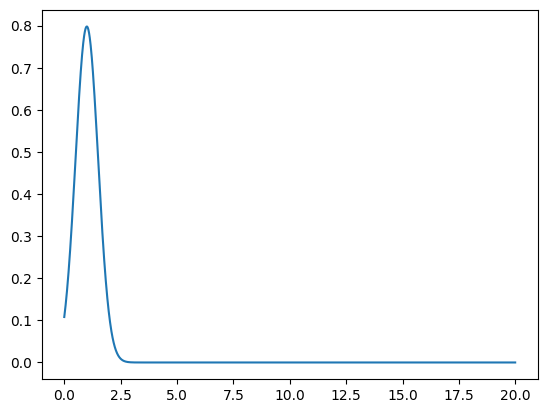

In [7]:
xs = np.arange(0, 20, 0.01)
plt.plot(xs, [np.abs(np.sum([wave(0, k, x) * 0.01 for k in np.arange(-10, 30, 0.01)])) ** 2 for x in xs])

In [8]:
gaussian = lambda k : (std_p * np.sqrt(2 * np.pi)) ** (-1 / 2) * np.exp(-(((hbar * k) ** 2 - b) / l) ** 2 / 4) * np.exp(-1j / hbar * (p - b) * a)

wave = lambda t : (lambda x : (lambda p : gaussian(p) * np.exp(1j / hbar * p * x) * np.exp(1j / hbar * p ** 2 * t)))

L = 5
r = lambda p : -1
reflected_wave = lambda t : (lambda x : (lambda p : gaussian(p) * r(p) * np.exp(-1j / hbar * p * x) * np.exp(1j / hbar * p ** 2 / 2 / m * t)))

xs = np.linspace(-20, 20, 200)

dp = 0.1
ps = np.arange(-100, 100, dp)
ps = ps.reshape((len(ps), 1))

ts = np.linspace(0, 15, 400)
psi = [(np.sum(wave(t)(xs)(ps), axis=0) + np.sum(reflected_wave(t)(xs)(ps), axis=0)) * dp for t in ts]

NameError: name 'b' is not defined

In [9]:
test_x = np.linspace(-20, 0, 500)
dx = test_x[1] - test_x[0]
test = np.sum(reflected_wave(0.3)(test_x)(ps) * dp, axis=0)
plt.plot(test_x, np.abs(test) ** 2)

print(np.sum(np.abs(test)) * dx)

NameError: name 'b' is not defined

NameError: name 'psi' is not defined

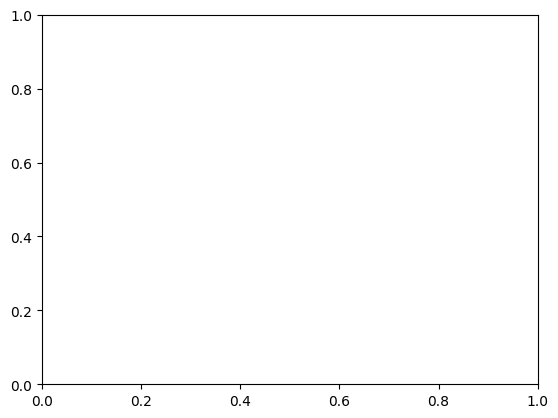

In [10]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs, psi[i])[0]
ax.set(xlim=[0, 20], ylim=[0, 5])

def update(frame):
    global i
    # update the line plot:
    i += 1
    line.set_ydata(np.abs(psi[i]) ** 2)
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
ani

In [11]:
l = 1
hbar = 1
a = 10
b = 10

gaussian = lambda p : (l * np.sqrt(2 * np.pi)) ** (-1 / 2) * np.exp(-((p - b) / l) ** 2 / 4) * np.exp(-1j / hbar * (p - b) * a)

wave = lambda t : (lambda x : (lambda p : gaussian(p) * np.exp(1j / hbar * p * x) * np.exp(1j / hbar * p ** 2 * t)))

L = 5
r = lambda p : np.exp(1j * (np.pi - 2 * p * L))
reflected_wave = lambda t : (lambda x : (lambda p : gaussian(p) * r(p) * np.exp(-1j / hbar * p * x) * np.exp(1j / hbar * p ** 2 * t)))

xs = np.linspace(0, 20, 200)

dp = 0.1
ps = np.arange(-100, 100, dp)
ps = ps.reshape((len(ps), 1))

ts = np.linspace(0, 15, 400)
psi = [(np.sum(wave(t)(xs)(ps), axis=0) + np.sum(reflected_wave(t)(xs)(ps), axis=0)) * dp for t in ts]

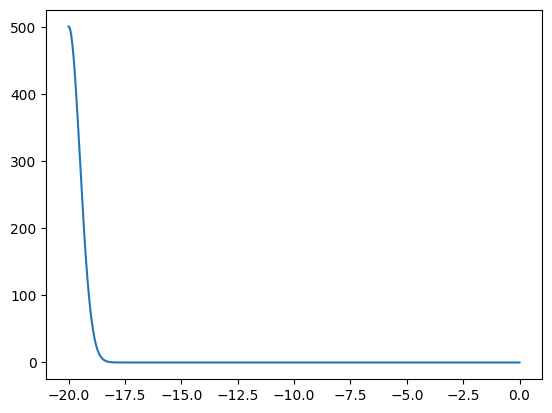

In [12]:
test_x = np.linspace(-20, 0, 500)
test = np.sum(reflected_wave(0)(test_x)(ps), axis=0)
plt.plot(test_x, np.abs(test) ** 2)

C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\kevin\AppData\Roaming\Python\Python312\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


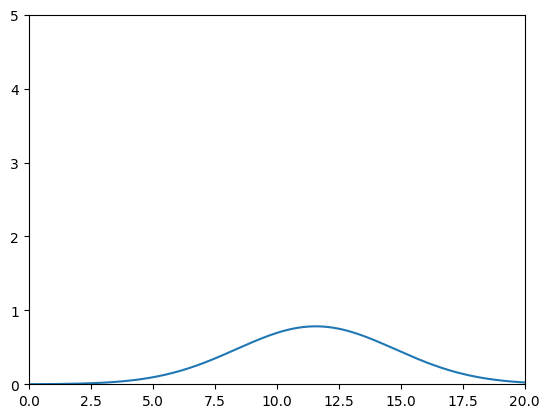

In [13]:
import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
line = ax.plot(xs, psi[i])[0]
ax.set(xlim=[0, 20], ylim=[0, 5])

def update(frame):
    global i
    # update the line plot:
    i += 1
    line.set_ydata(np.abs(psi[i]) ** 2)
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=40, interval=30)
ani

In [33]:
hbar = 1
std_k = 0.1
std_x = 1 / std_k
x0 = 20
k0 = -5

def gaussian_envelope(k):
    normalization = 1 / np.sqrt((std_k * np.sqrt(2 * np.pi)))
    phase = np.exp(-1j * (k - k0) * x0)
    gaussian = np.exp(-((k - k0) / std_k) ** 2 / 4)
    return normalization * gaussian * phase

def wave(t, k, x):
    position = np.exp(1j * k * x)
    time_evolution = np.exp(-1j * k ** 2 * t)
    return gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)

def reflected_wave(t, k, x, r):
    position = np.exp(-1j * k * x)
    time_evolution = np.exp(-1j * k ** 2 * t)
    return r(k) * gaussian_envelope(k) * position * time_evolution / np.sqrt(2 * np.pi)


In [30]:
xs = np.linspace(-100, 100, 200)

ps = np.linspace(k0 - 3 * std_k, k0 + 3 * std_k, 500)
dp = ps[1] - ps[0]
ps = ps.reshape((len(ps), 1))

ts = np.linspace(0, 10, 300)

In [41]:
r0 = lambda k : np.exp(0)
psi0 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r0), axis=0)) * dp for t in ts])

# psi = psi1
# mean1 = np.sum(np.abs(psi) ** 2 * xs, axis=1) / np.sum(np.abs(psi) ** 2, axis=1) 
# mask = xs > 0
# mean1_g0 = np.sum(np.abs(psi[:,mask]) ** 2 * xs[mask], axis=1) / np.sum(np.abs(psi[:,mask]) ** 2, axis=1) 

In [48]:
length = 5

r1 = lambda k : np.exp(-1j * 2 * k * length) 
# r1 = lambda k : np.exp(1j * 0.2)
psi1 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r1), axis=0)) * dp for t in ts])

In [18]:
delta2 = 3

r2 = lambda k : np.exp(-1j * 2 * k ** 2 * delta2) 
psi2 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r2), axis=0)) * dp for t in ts])

In [53]:
gamma = 2
kres = 4.9

phase = lambda k : -2 * np.arctan(gamma / (k ** 2 - kres ** 2))

r3 = lambda k : np.exp(1j * phase(k)) 
psi3 = np.array([(np.sum(wave(t, ps, xs) + reflected_wave(t, ps, xs, r3), axis=0)) * dp for t in ts])

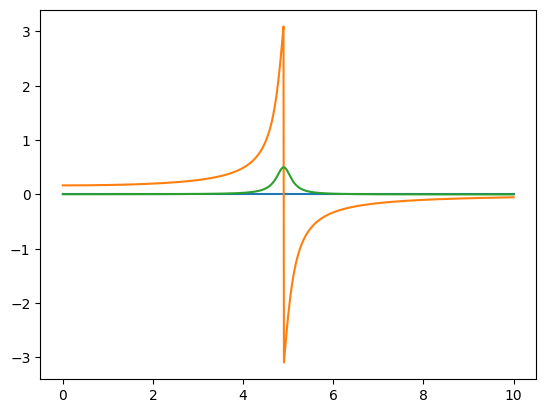

In [54]:
gamma = 2
kres = 4.9

time_delay = lambda k : gamma / ((k ** 2 - kres ** 2) ** 2 + gamma ** 2)

ks = np.linspace(0, 10, 1000)
plt.plot(ks, np.abs(gaussian_envelope(ks)))
plt.plot(ks, phase(ks))
plt.plot(ks, time_delay(ks))
plt.show()

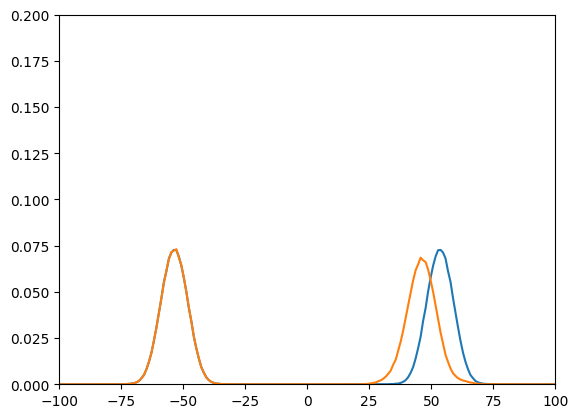

In [55]:
psis = [psi0, psi3]

import matplotlib.animation as animation
plt.rcParams["animation.html"] = "jshtml"

i = 0
fig, ax = plt.subplots()
lines = []
for psi in psis:
    line = ax.plot(xs, np.abs(psi[i]) ** 2)[0]
    lines.append(line)
ax.set(xlim=[-100, 100], ylim=[0, 0.2])

num = 1000
# line2 = ax.plot([mean1[0] for i in range(num)], [i / num for i in range(num)], color='red')[0]
# line3 = ax.plot([mean1_g0[0] for i in range(num)], [i / num for i in range(num)], color='green')[0]

def update(frame):
    global i
    # update the line plot:
    i += 10
    for j in range(len(psis)):
        lines[j].set_ydata(np.abs(psis[j][i]) ** 2)
    # line2.set_xdata([mean1[i] for j in range(num)])
    # line3.set_xdata([mean1_g0[i] for j in range(num)])
    return line


ani = animation.FuncAnimation(fig=fig, func=update, frames=20, interval=30)
ani